In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [63]:
df = pd.read_csv("Churn_Modelling.csv")

In [64]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [65]:
df.shape

(10000, 14)

In [66]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [67]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [68]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [69]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [70]:
le = LabelEncoder()

In [71]:
df['Geography'] = le.fit_transform(df['Geography'])

In [72]:
le1 = LabelEncoder()

In [73]:
df['Gender'] = le.fit_transform(df['Gender'])

In [74]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [75]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [76]:
X = df.drop(columns=['Exited'])
Y = df['Exited']

In [77]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=.2)

In [78]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [79]:
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

In [80]:
# pip install tensorflow
# !pip install keras


In [81]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(11, activation='sigmoid', input_dim = 10))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [83]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 11)             │           121 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265 (1.04 KB)

 Trainable params: 265 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [85]:
history = model.fit(x_train, y_train, batch_size=50, epochs=100, verbose=1, validation_split=.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7306 - loss: 0.5923 - val_accuracy: 0.7987 - val_loss: 0.5104
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.5038 - val_accuracy: 0.7987 - val_loss: 0.4880
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4922 - val_accuracy: 0.7987 - val_loss: 0.4783
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4838 - val_accuracy: 0.7987 - val_loss: 0.4696
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4749 - val_accuracy: 0.7987 - val_loss: 0.4604
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4660 - val_accuracy: 0.7987 - val_loss: 0.4517
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4577 - val_accuracy: 0.7987 - val_loss: 0.4438
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4509 - val_accu

In [86]:
y_pred = model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step


In [87]:
y_pred

array([[0.09477498],
       [0.10851394],
       [0.4159217 ],
       ...,
       [0.57967407],
       [0.05362189],
       [0.13622612]], shape=(2000, 1), dtype=float32)

In [88]:
y_pred[0]

array([0.09477498], dtype=float32)

In [89]:
y_pred = y_pred.argmax(axis=1)

In [90]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [91]:
from sklearn.metrics import accuracy_score

In [92]:
accuracy_score(y_test, y_pred)

0.8035

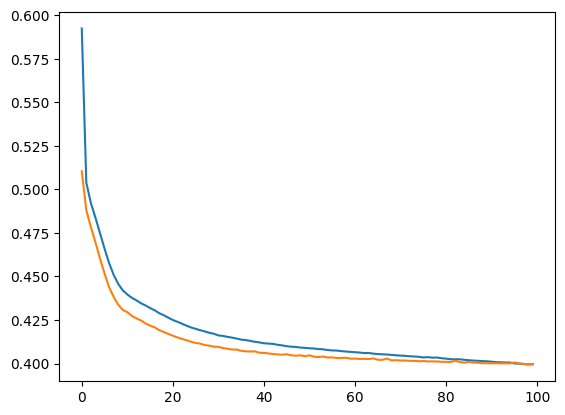

In [93]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])